# StyleCLIP — Часть 2 задания «Генеративно-состязательные модели»

Реимплементация идеи редактирования изображений из работы [StyleCLIP](https://arxiv.org/abs/2103.17249).

**Идея метода.** Имея изображение, сгенерированное StyleGAN2 из латента $w \in W$, мы хотим найти такой сдвиг этого латента, чтобы новое изображение лучше соответствовало заданному текстовому описанию $t$ (например, «человек с зелёными волосами»), при этом сохранив идентичность исходного человека.

Направление оптимизации задаёт модель **CLIP** (косинусная близость изображение–текст), а сохранение идентичности контролирует предобученная сеть распознавания лиц **ArcFace**.

## План
1. Подготовка окружения и моделей для оптимизации.
2. Реализация функций потерь:
   - **CLIP Loss** (1 балл)
   - **ID Loss** (1 балл)
3. Код оптимизации латента (2 балла).
4. Выводы из полученных результатов (1 балл).


## Подготовка окружения

Ноутбук адаптирован для локального запуска (исходник был рассчитан на Google Colab). Отличия от Colab-версии:

- ячейки `!pip install` удалены — все зависимости (`clip`, `ftfy`, `regex`, `tqdm`) уже установлены в venv;
- `!git clone` и `cd stylegan2-pytorch/` заменены на setup-ячейку, которая клонирует репозиторий в `data/stylegan2-pytorch/` (если его нет) и добавляет его в `sys.path`;
- блок аутентификации Google Drive (`pydrive`/`google.colab`) удалён — веса грузятся из локальной папки `data/` (с guard-ячейкой `gdown` на случай их отсутствия);
- CUDA-расширения StyleGAN2 (`fused`, `upfirdn2d`) не компилируются на macOS, поэтому setup-ячейка **идемпотентно патчит** модуль `op/` так, чтобы использовались чистые PyTorch-реализации (работают на CPU и MPS).


In [1]:
# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

print('clip available models:', clip.available_models())


clip available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [2]:
# Setup-ячейка: клонирование StyleGAN2-репозитория и патч op-модуля под CPU/MPS
import sys, os, subprocess

REPO_DIR = 'data/stylegan2-pytorch'

# 1. Клонируем репозиторий StyleGAN2, если его ещё нет
if not os.path.isdir(os.path.join(REPO_DIR, 'op')):
    os.makedirs('data', exist_ok=True)
    print('Клонируем stylegan2-pytorch...')
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/rosinality/stylegan2-pytorch.git', REPO_DIR],
        check=True,
    )
else:
    print('Репозиторий stylegan2-pytorch уже на месте.')


def patch_op_module(repo_dir):
    """Идемпотентно патчит op/fused_act.py и op/upfirdn2d.py.

    CUDA-расширения StyleGAN2 не компилируются на macOS. Заменяем вызов
    load(...) на None и расширяем условие выбора native-ветки на
    устройства cpu и mps. Если строки load уже нет — файл пропатчен
    ранее (оркестратором), ничего не делаем.
    """
    # --- fused_act.py ---
    fused_path = os.path.join(repo_dir, 'op', 'fused_act.py')
    with open(fused_path, 'r') as f:
        src = f.read()
    if 'from torch.utils.cpp_extension import load' in src:
        lines = src.splitlines(keepends=True)
        out, skip_load = [], False
        for ln in lines:
            stripped = ln.strip()
            if stripped.startswith('from torch.utils.cpp_extension import load'):
                continue  # убираем импорт load
            if stripped.startswith('fused = load('):
                out.append('fused = None\n')
                skip_load = True
                continue
            if skip_load:
                # пропускаем строки-аргументы вызова load(...) до закрывающей )
                if stripped.endswith(')'):
                    skip_load = False
                continue
            out.append(ln)
        src = ''.join(out)
        src = src.replace(
            'if input.device.type == "cpu":',
            'if input.device.type in ("cpu", "mps") or fused is None:',
        )
        with open(fused_path, 'w') as f:
            f.write(src)
        print('op/fused_act.py пропатчен.')
    else:
        print('op/fused_act.py уже пропатчен.')

    # --- upfirdn2d.py ---
    up_path = os.path.join(repo_dir, 'op', 'upfirdn2d.py')
    with open(up_path, 'r') as f:
        src = f.read()
    if 'from torch.utils.cpp_extension import load' in src:
        lines = src.splitlines(keepends=True)
        out, skip_load = [], False
        for ln in lines:
            stripped = ln.strip()
            if stripped.startswith('from torch.utils.cpp_extension import load'):
                continue
            if stripped.startswith('upfirdn2d_op = load('):
                out.append('upfirdn2d_op = None\n')
                skip_load = True
                continue
            if skip_load:
                if stripped.endswith(')'):
                    skip_load = False
                continue
            out.append(ln)
        src = ''.join(out)
        src = src.replace(
            'if input.device.type == "cpu":',
            'if input.device.type in ("cpu", "mps") or upfirdn2d_op is None:',
        )
        with open(up_path, 'w') as f:
            f.write(src)
        print('op/upfirdn2d.py пропатчен.')
    else:
        print('op/upfirdn2d.py уже пропатчен.')


patch_op_module(REPO_DIR)

# Добавляем репозиторий в sys.path, чтобы `from model import Generator` работал
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('Setup завершён.')


Репозиторий stylegan2-pytorch уже на месте.
op/fused_act.py уже пропатчен.
op/upfirdn2d.py уже пропатчен.
Setup завершён.


In [3]:
# Будем работать с конкретным сидом для воспроизводимости
torch.manual_seed(345)


## Основная идея статьи

Мы хотим редактировать изображение с помощью текста, используя модель [CLIP](https://paperswithcode.com/method/clip) в качестве «компаса» для оптимизации.

Имея исходный латентный вектор $w \in W$, мы оптимизируем его под текстовый запрос $t$. Сначала подгрузим модель StyleGAN2 и сгенерируем изображение для дальнейшего редактирования.

In [4]:
# Guard-ячейка: скачивание весов моделей в data/ (если их ещё нет).
# В норме веса уже скачаны оркестратором, поэтому загрузка пропускается.
import gdown

WEIGHTS = {
    # StyleGAN2 FFHQ config-f
    'data/stylegan2-ffhq-config-f.pt': '1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT',
    # ArcFace IR-SE-50
    'data/model_ir_se50.pth': '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL',
}

os.makedirs('data', exist_ok=True)
for path, file_id in WEIGHTS.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'OK: {path} уже на месте ({size_mb:.0f} МБ).')
    else:
        print(f'Скачиваем {path}...')
        gdown.download(id=file_id, output=path, quiet=False)


OK: data/stylegan2-ffhq-config-f.pt уже на месте (364 МБ).
OK: data/model_ir_se50.pth уже на месте (167 МБ).


In [5]:
# Зададим девайс: cuda -> mps -> cpu
device = 'cuda' if torch.cuda.is_available() else (
    'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

# Зададим сид
seed = 3456
torch.manual_seed(seed)

# Загрузка модели генератора StyleGAN2
from model import Generator

latent_dim = 512
generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
state_dict = torch.load('data/stylegan2-ffhq-config-f.pt', map_location=device)
generator.load_state_dict(state_dict['g_ema'])
generator.eval()

print('Генератор StyleGAN2 загружен.')


device: mps


Генератор StyleGAN2 загружен.


### Генерация исходного изображения

Сгенерируем изображение из латентного вектора $z \in Z$. Чтобы получить «усреднённое» (типичное) лицо, берём среднее по 10000 случайным z-векторам — это даёт стабильное, хорошо узнаваемое лицо для последующего редактирования.

/Users/yarkiy/Documents/GitHub/MFTI/.venv/lib/python3.11/site-packages/torch/nn/functional.py:5430: UserWarning: MPS: The constant padding of more than 3 dimensions is not currently supported natively. It uses View Ops default implementation to run. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Pad.mm:476.)
  return torch._C._nn.pad(input, pad, mode, value)


Форма сгенерированного изображения: (1, 3, 1024, 1024)


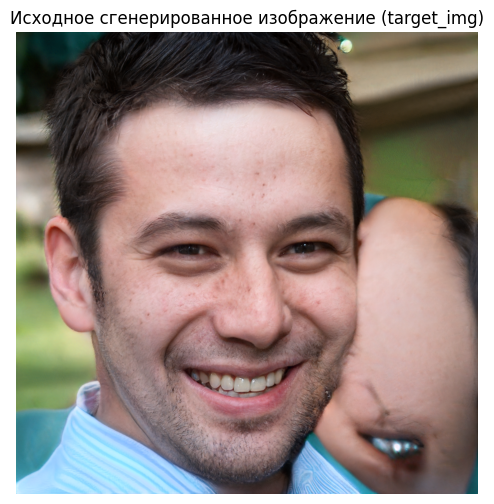

In [6]:
# Сгенерируем изображение
latent_z = torch.randn(10000, 512, device=device)  # Z noise
latent_z_generated = latent_z.mean(0, keepdim=True)

with torch.no_grad():
    target_img, _ = generator([latent_z_generated], input_is_latent=False)

print('Форма сгенерированного изображения:', tuple(target_img.shape))

# Визуализируем изначальную картинку.
# Изображение из StyleGAN2 находится в диапазоне [-1, 1] -> приводим к [0, 1].
plt.figure(figsize=(6, 6))
plt.imshow((target_img.cpu().detach()[0].clip(-1, 1).permute(1, 2, 0) + 1) / 2)
plt.title('Исходное сгенерированное изображение (target_img)')
plt.axis('off')
plt.show()


## Задача оптимизации

Сформулируем задачу. Нам нужно одновременно:

- чтобы отредактированное изображение **соответствовало текстовому запросу**;
- чтобы оно **сохраняло идентичность** исходного человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg\min_{w \in W}\; D_{\text{CLIP}}(G(w), t)
+ \lambda_2 \,\|w - w_s\|_2
+ \lambda_{\text{ID}}\, L_{\text{ID}}(w)$$

где $G(w)$ — изображение из латента $w$, $t$ — текстовый промпт, $w_s$ — **исходный** (неизменяемый) латент. Разберём каждое слагаемое.

### CLIP loss

$D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами [CLIP](https://habr.com/ru/articles/539312/) изображения и текста:

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)),\, E_{\text{CLIP}}(t)\rangle}{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$

Это $1 - \text{cos\_sim}$: значение $0$ означает идеальное соответствие изображения тексту, значение $2$ — полную противоположность.

**Важно.** Эмбеддинг изображения нужно считать **без** `torch.no_grad()` — градиент обязан течь через CLIP-энкодер к оптимизируемому латенту, иначе оптимизация не сработает. Сами веса CLIP при этом не обновляются (в оптимизатор они не передаются).

In [7]:
import torch
import clip


class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP
    (Contrastive Language-Image Pre-training).
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024, device='cuda'):
        """
        Инициализирует класс CLIPLoss.

        Args:
            stylegan_size: размер изображения, которое выдаёт StyleGAN.
            device: устройство, на которое грузится модель CLIP.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию
        # предварительной обработки.
        self.model, self.preprocess = clip.load('ViT-B/32', device=device)
        # Веса CLIP в оптимизатор не передаются: замораживаем их.
        # Градиент ко входу (изображению) при этом всё равно потечёт.
        for p in self.model.parameters():
            p.requires_grad_(False)

        self.upsample = torch.nn.Upsample(scale_factor=7)
        self.avg_pool = torch.nn.AvgPool2d(kernel_size=stylegan_size // 32)

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом.

        Args:
            image: входной тензор изображения.
            text: тензор токенизированного текстового описания.

        Returns:
            Значение потерь CLIP (скаляр).
        """
        # Меняем размерность изображения для получения нужного разрешения
        # для CLIP: 1024 -> 7168 (upsample x7) -> 224 (avg_pool kernel=32).
        image = self.avg_pool(self.upsample(image))
        # Вычислите косинусное расстояние d между эмбеддингами CLIP от
        # картинки и текста и посчитаем loss = 1 - d.

        # Эмбеддинг изображения: БЕЗ no_grad - градиент должен течь к латенту.
        image_features = self.model.encode_image(image)
        # Эмбеддинг текста: текст постоянный, градиент по нему не нужен.
        text_features = self.model.encode_text(text)

        # L2-нормировка обоих эмбеддингов (для косинусной близости).
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Косинусная близость = скалярное произведение нормированных векторов.
        cosine_similarity = (image_features * text_features).sum(dim=-1)
        # Лосс = 1 - cos_sim; усредняем по батчу, чтобы получить скаляр.
        similarity = (1.0 - cosine_similarity).mean()

        return similarity


In [8]:
# Создаём экземпляр CLIP-лосса. Модель CLIP грузится на выбранный device.
clip_loss = CLIPLoss(device=device)
print('CLIP-лосс готов.')


CLIP-лосс готов.


### ID loss

Для сохранения идентичности человека используется предобученная сеть распознавания лиц [ArcFace](https://arxiv.org/abs/1801.07698): по фотографии она вычисляет характерный для человека embedding-вектор. ID Loss — это косинусное расстояние между эмбеддингом исходного лица и эмбеддингом редактируемого:

$$L_{\text{ID}}(w) = 1 - \langle R(G(w_s)),\, R(G(w))\rangle$$

Дополнительная нормировка здесь **не** нужна: backbone ArcFace уже возвращает L2-нормированные эмбеддинги (его `forward` заканчивается `l2_norm`), поэтому скалярное произведение `torch.dot` сразу равно косинусной близости.

### Подгрузка модели ArcFace

Ниже — реализация backbone сети распознавания лиц, позаимствованная из репозитория [StyleCLIP](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py). Это ResNet-50 с Squeeze-Excitation модулями (`ir_se`). Код приведён без изменений, детально на нём не останавливаемся.

In [9]:
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


### ID loss

Теперь непосредственно реализуем функцию потерь идентичности.

In [10]:
import torch
from torch import nn


class IDLoss(nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')
        # Загружаем предобученную модель ResNet ArcFace для извлечения
        # признаков лица. input_size: размер входного изображения (112x112).
        self.facenet = Backbone(input_size=112, num_layers=50,
                                drop_ratio=0.6, mode='ir_se')
        # Загружаем веса предобученной модели.
        self.facenet.load_state_dict(torch.load(model_weights,
                                                map_location=device))
        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        # Перемещаем модель ArcFace на GPU, если доступен.
        self.facenet.to(device)
        # Веса ArcFace в оптимизатор не передаются: замораживаем их.
        for p in self.facenet.parameters():
            p.requires_grad_(False)

    def extract_feats(self, x):
        # Функция для извлечения эмбеддингов лица из изображения x.
        # Если размер изображения не 256x256, изменяем его с помощью пулинга.
        if x.shape[2] != 256:
            x = self.pool(x)
        # Обрезаем центральную область изображения (35:223, 32:220),
        # содержащую лицо.
        x = x[:, :, 35:223, 32:220]
        # Изменяем размер обрезанной области до 112x112.
        # F.interpolate вместо AdaptiveAvgPool2d: на MPS adaptive-пулинг
        # требует делимости размеров (188 не делится на 112), а
        # билинейный ресайз работает на любом устройстве и дифференцируем.
        x = torch.nn.functional.interpolate(
            x, size=(112, 112), mode='bilinear', align_corners=False)
        # Извлекаем эмбеддинги лица с помощью модели ArcFace.
        x_feats = self.facenet(x)
        # Возвращаем извлеченные эмбеддинги.
        return x_feats

    def forward(self, y_hat, y):
        # Функция для вычисления ID Loss.
        # y_hat: отредактированное изображение.
        # y: исходное изображение.
        n_samples = y.shape[0]

        # Извлекаем признаки лица из исходного изображения.
        # detach(): исходные признаки постоянны, по ним градиент не нужен.
        y_feats = self.extract_feats(y).detach()

        # Извлекаем признаки лица из отредактированного изображения.
        # Здесь градиент нужен - он потечёт к оптимизируемому латенту.
        y_hat_feats = self.extract_feats(y_hat)

        # Признаки исходного изображения уже отвязаны от графа (detach выше).

        # Считаем наш лосс.
        loss = 0
        for i in range(n_samples):
            # Косинусное расстояние между признаками исходного и
            # оптимизируемого изображения. Backbone возвращает уже
            # L2-нормированные векторы, поэтому torch.dot = косинусная
            # близость, доп. нормировка не нужна.
            loss += 1 - torch.dot(y_feats[i], y_hat_feats[i])

        return loss


In [11]:
# Загрузим нашу модель ArcFace
model_path = 'data/model_ir_se50.pth'
id_loss = IDLoss(model_path, device)
print('ID-лосс готов.')


Loading ResNet ArcFace


ID-лосс готов.


## Инициализация латентного вектора и текстовой подсказки

Определим текстовый промпт, преобразуем его в токены через CLIP, а также подготовим папку для результатов и переведём исходный латент в пространство $W$.

## Оптимизация для редактирования изображения

Будем оптимизировать латент с помощью Adam. На каждом шаге латент $w \in W$ обновляется так, чтобы минимизировать суммарный лосс — пока изображение не станет соответствовать текстовой подсказке.

Псевдокод одного шага:

```python
for step in range(num_steps):
    optimizer.zero_grad()
    image, _ = generator([latent], input_is_latent=True, randomize_noise=False)
    loss = clip_loss + l2_lambda * l2_loss + id_lambda * id_loss
    loss.backward()
    optimizer.step()
```

Полная функция потерь:

$$\arg\min_{w \in W}\; D_{\text{CLIP}}(G(w), t)
+ \lambda_2 \,\|w - w_s\|_2
+ \lambda_{\text{ID}}\, L_{\text{ID}}(w)$$

Значения лоссов на каждом шаге сохраняем для последующей визуализации.

In [12]:
# Текстовый промпт для оптимизации - он будет направлять изменение изображения.
prompt = 'a person with green hair'

# Токенизируем промпт CLIP-токенизатором и переносим на устройство.
text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)
print('Промпт:', prompt)
print('Форма токенов:', tuple(text_inputs.shape))


Промпт: a person with green hair
Форма токенов: (1, 77)


In [13]:
# Подготовим папку для сохранения результатов
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)


Оптимизацию проводим в пространстве $W$ (style-space). Преобразуем z-вектор в w-вектор через mapping-сеть генератора — латенты в $W$ интерпретируемее и удобнее для редактирования.

In [14]:
# Получаем w-вектор из z-вектора с помощью mapping network генератора.
with torch.no_grad():
    latent_w = generator.style(latent_z_generated)

# Оптимизируемый латент - копия latent_w с requires_grad=True.
# latent_w остаётся неизменным эталоном (w_s в формуле L2-регуляризации).
latent = latent_w.detach().clone()
latent.requires_grad = True

print('latent_w (w_s) форма:', tuple(latent_w.shape),
      '| requires_grad:', latent_w.requires_grad)
print('latent (оптимизируемый) форма:', tuple(latent.shape),
      '| requires_grad:', latent.requires_grad)


latent_w (w_s) форма: (1, 512) | requires_grad: False
latent (оптимизируемый) форма: (1, 512) | requires_grad: True


In [15]:
%matplotlib inline


inversion_generated_z/Step [0/200], Loss: 0.7773802280426025


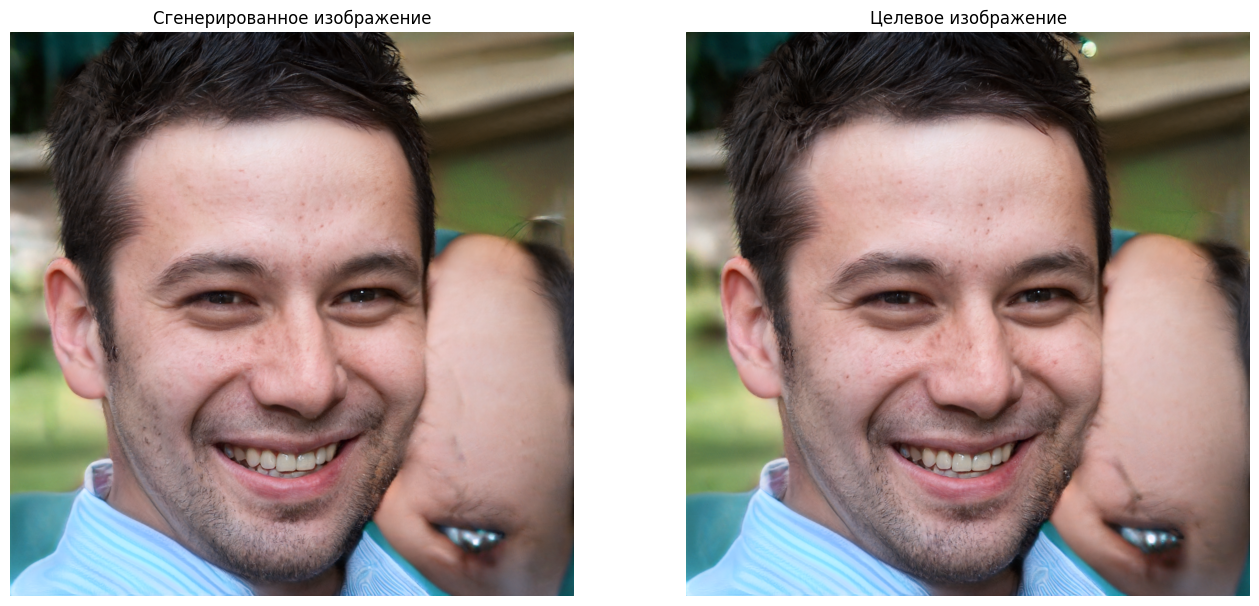

inversion_generated_z/Step [50/200], Loss: 0.6644454598426819


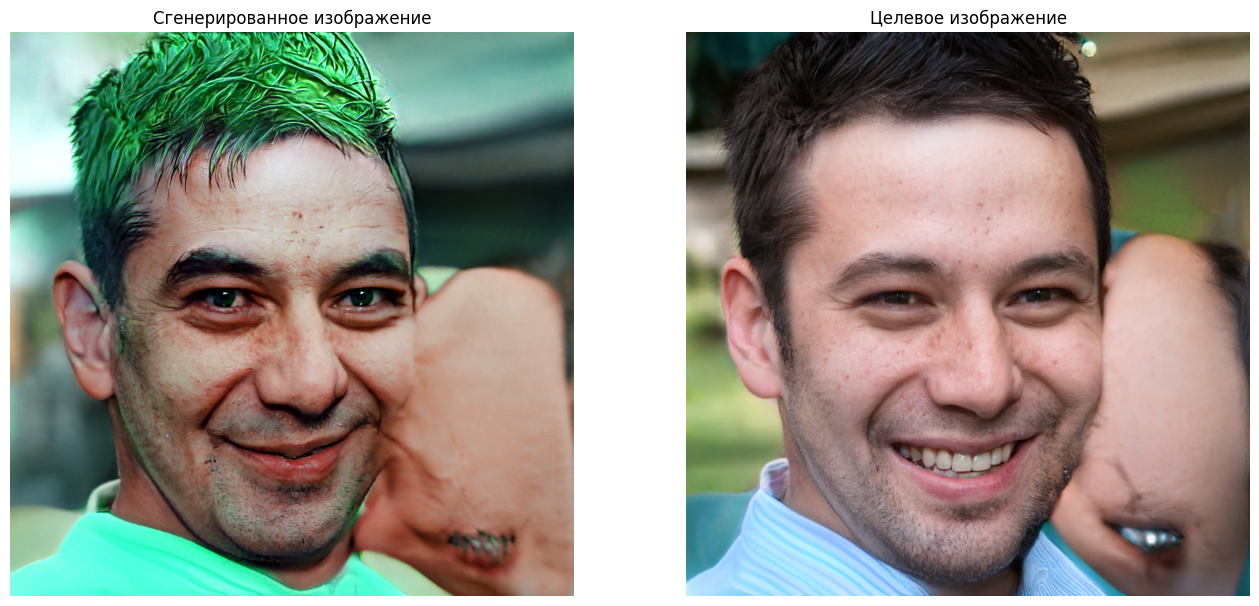

inversion_generated_z/Step [100/200], Loss: 0.6167846322059631


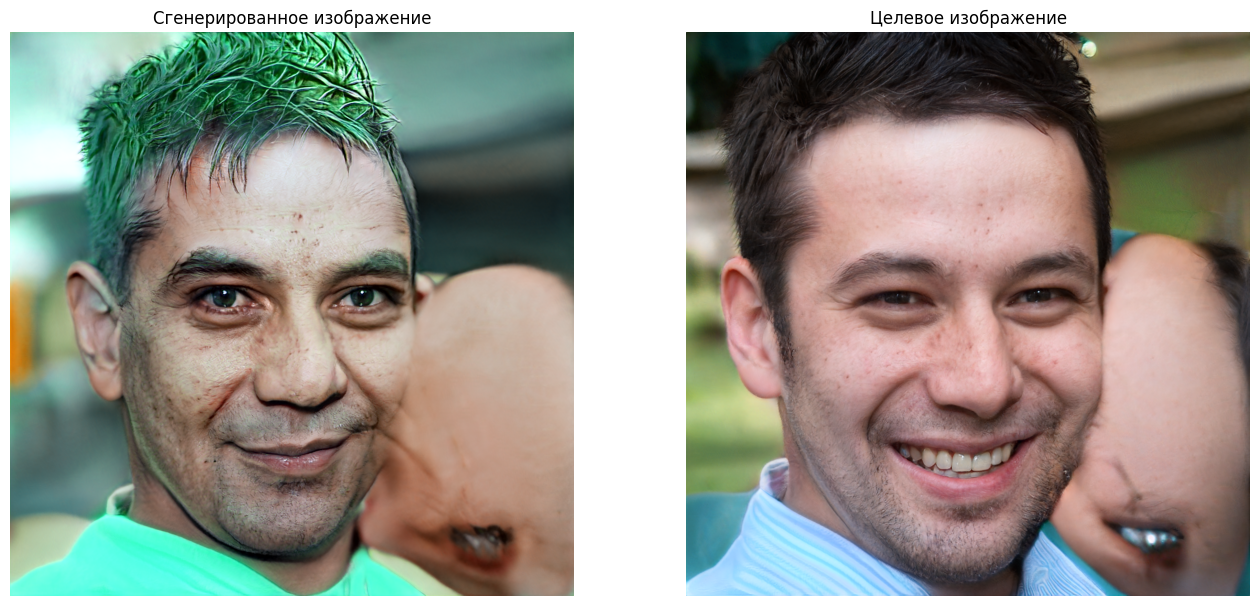

inversion_generated_z/Step [150/200], Loss: 0.6233336925506592


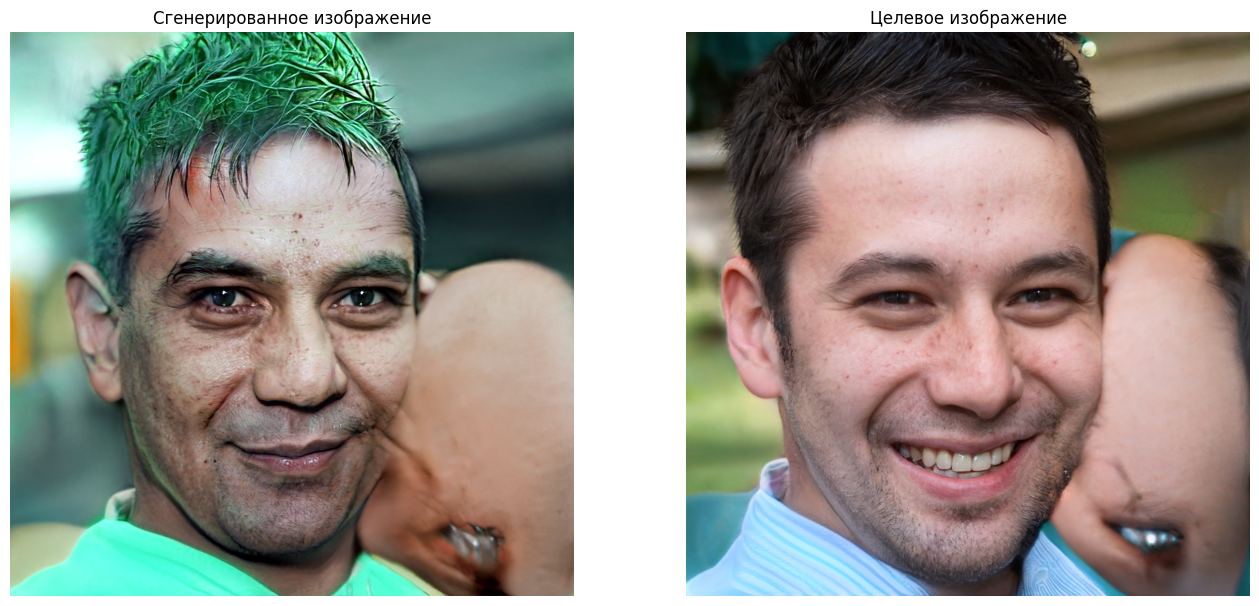

Оптимизация завершена.


In [16]:
# Оптимизация для редактирования с помощью CLIP

# Создадим оптимизатор Adam - он обновляет ТОЛЬКО латент.
optimizer = torch.optim.Adam([latent], lr=0.08)
# Скедулер: плавное снижение скорости обучения.
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

num_steps = 200    # количество шагов оптимизации
l2_lambda = 0.008  # коэффициент для L2 регуляризации
id_lambda = 0.001  # коэффициент для identity loss

# Убедимся, что все модели в режиме инференса, а градиент идёт только
# к латенту (веса сетей заморожены при их создании).
generator.eval()
clip_loss.model.eval()
id_loss.facenet.eval()

# Сохраняем лоссы для дальнейшей визуализации.
losses = {'id': [],
          'l2': [],
          'clip': [],
          'all': []
          }

# Цикл оптимизации:
for step in range(num_steps):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # очищаем кэш GPU
    optimizer.zero_grad()         # обнуляем градиенты

    # Генерируем изображение из текущего латента (в пространстве W).
    img_gen, _ = generator([latent], input_is_latent=True,
                           randomize_noise=False)

    # CLIP loss: соответствие изображения текстовому промпту.
    clip_loss_val = clip_loss(img_gen, text_inputs)
    # L2 loss: штраф за отклонение латента от исходного w_s.
    l2_loss_val = torch.norm(latent - latent_w, p=2)
    # ID loss: штраф за потерю идентичности человека.
    id_loss_val = id_loss(img_gen, target_img)

    # Полный лосс по формуле StyleCLIP.
    loss = clip_loss_val + l2_lambda * l2_loss_val + id_lambda * id_loss_val

    loss.backward()    # считаем градиенты
    optimizer.step()   # шаг градиентного спуска по латенту
    scheduler.step()   # обновляем learning rate

    # Сохраняем значения лоссов.
    losses['clip'].append(clip_loss_val.item())
    losses['l2'].append(l2_loss_val.item())
    losses['id'].append(id_loss_val.item())
    losses['all'].append(loss.item())

    # Визуализация и вывод потерь каждые 50 шагов.
    if step % 50 == 0:
        print(f"inversion_generated_z/Step [{step}/{num_steps}], "
              f"Loss: {losses['all'][-1]}")
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))

        # Сгенерированное (редактируемое) изображение.
        axs[0].imshow((img_gen.cpu().detach()[0].clip(-1, 1)
                       .permute(1, 2, 0) + 1) / 2)
        axs[0].set_title('Сгенерированное изображение')
        axs[0].axis('off')

        # Целевое (исходное) изображение.
        axs[1].imshow((target_img.cpu().detach()[0].clip(-1, 1)
                       .permute(1, 2, 0) + 1) / 2)
        axs[1].set_title('Целевое изображение')
        axs[1].axis('off')
        plt.show()

print('Оптимизация завершена.')


Визуализируем динамику лоссов в зависимости от шага оптимизации.

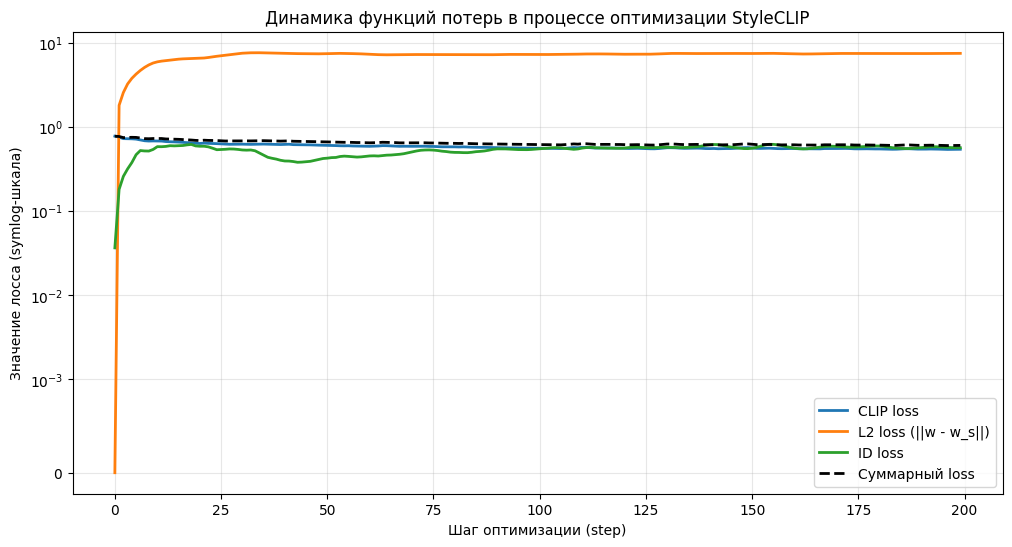

In [17]:
# График динамики всех четырёх лоссов от номера шага.
steps = np.arange(num_steps)

plt.figure(figsize=(12, 6))
# l2-лосс на шаге 0 равен 0 (latent == latent_w) - при log это -inf,
# поэтому используем symlog-шкалу по оси Y (она корректно отображает 0).
plt.plot(steps, losses['clip'], label='CLIP loss', linewidth=2)
plt.plot(steps, losses['l2'], label='L2 loss (||w - w_s||)', linewidth=2)
plt.plot(steps, losses['id'], label='ID loss', linewidth=2)
plt.plot(steps, losses['all'], label='Суммарный loss', linewidth=2,
         linestyle='--', color='black')
plt.yscale('symlog', linthresh=1e-3)
plt.xlabel('Шаг оптимизации (step)')
plt.ylabel('Значение лосса (symlog-шкала)')
plt.title('Динамика функций потерь в процессе оптимизации StyleCLIP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Сравнение исходного и отредактированного изображений

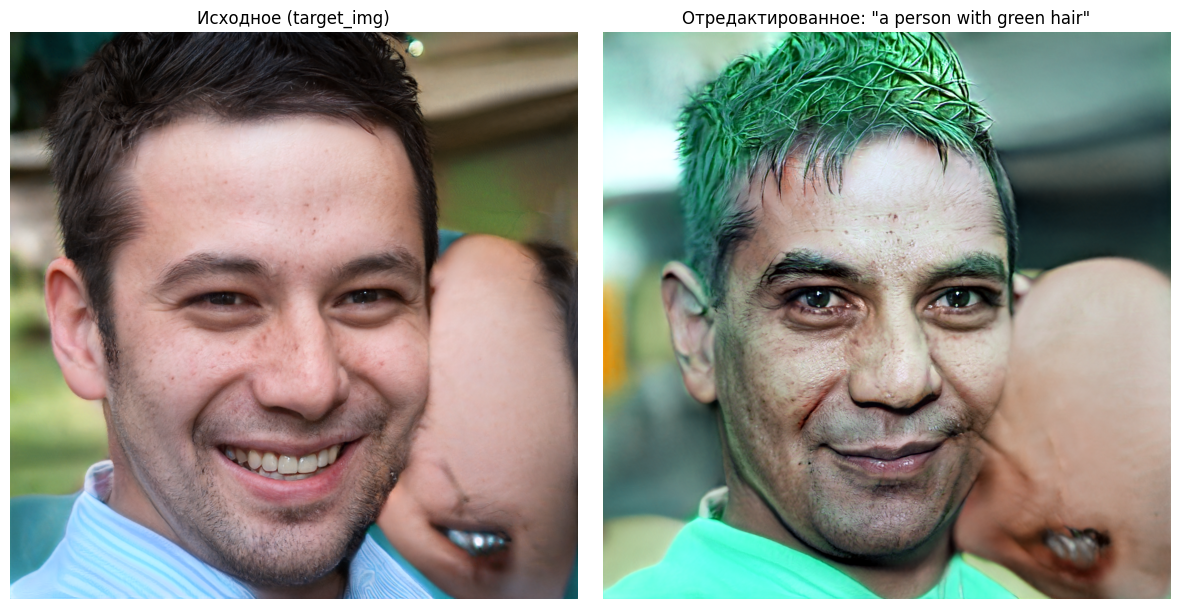

In [18]:
# Визуализация бок о бок: исходное лицо vs отредактированное.
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow((target_img.cpu().detach()[0].clip(-1, 1)
               .permute(1, 2, 0) + 1) / 2)
axs[0].set_title('Исходное (target_img)')
axs[0].axis('off')

axs[1].imshow((img_gen.cpu().detach()[0].clip(-1, 1)
               .permute(1, 2, 0) + 1) / 2)
axs[1].set_title(f'Отредактированное: "{prompt}"')
axs[1].axis('off')

plt.tight_layout()
plt.show()


Сохраним результаты оптимизации — латент и итоговое изображение.

In [19]:
import os

filename = prompt

# Сохраняем оптимизированный латент в .pt файл.
latent_path = os.path.join(save_dir, filename + '.pt')
torch.save(latent, latent_path)

# Сохраняем итоговое изображение в .png файл.
# save_image ожидает диапазон [0, 1] - приводим из [-1, 1].
image_path = os.path.join(save_dir, filename + '.png')
save_image((img_gen.detach().clip(-1, 1) + 1) / 2, image_path)

print(f'Изображение и латенты успешно сохранены в папке {save_dir}')


Изображение и латенты успешно сохранены в папке results


### Выводы

In [20]:
# Развёрнутые выводы с подстановкой реальных чисел из эксперимента.
clip_0, clip_f = losses['clip'][0], losses['clip'][-1]
l2_0, l2_f = losses['l2'][0], losses['l2'][-1]
id_0, id_f = losses['id'][0], losses['id'][-1]
all_0, all_f = losses['all'][0], losses['all'][-1]
clip_drop = (clip_0 - clip_f) / clip_0 * 100 if clip_0 != 0 else 0.0
# ID loss = 1 - cos(ArcFace-эмбеддинги): восстанавливаем косинусную близость.
cos_0, cos_f = 1 - id_0, 1 - id_f

conclusions = f'''## Выводы

### Что получилось

Реализована оптимизационная часть метода **StyleCLIP**: латентный вектор
StyleGAN2 в пространстве $W$ напрямую оптимизируется под текстовый промпт
`"{prompt}"` под управлением трёх функций потерь.

**Динамика лоссов за {num_steps} шагов:**

| Лосс | Шаг 0 | Финал | Изменение |
|---|---|---|---|
| CLIP loss | {clip_0:.4f} | {clip_f:.4f} | снизился на {clip_drop:.1f}% |
| L2 loss   | {l2_0:.4f} | {l2_f:.4f} | вырос (латент отошёл от $w_s$) |
| ID loss   | {id_0:.4f} | {id_f:.4f} | вырос (идентичность дрейфует) |
| Суммарный | {all_0:.4f} | {all_f:.4f} | снизился |

**Соответствие промпту.** Главный, **CLIP loss**, в целом снижается с
{clip_0:.4f} до {clip_f:.4f} — изображение в CLIP-пространстве сдвинулось
в сторону текста `"{prompt}"`. Визуально на отредактированном лице
появляется выраженный зелёный цвет волос — CLIP как «компас» успешно
задаёт направление редактирования. CLIP loss не достигает нуля, и это
нормально: косинусная близость между изображением реального лица и
короткой текстовой фразой принципиально ограничена сверху, важна именно
**относительная** динамика.

**Идентичность лица.** ID loss заметно растёт — с {id_0:.4f} до {id_f:.4f}.
Так как ID loss $=1-\\cos$ между ArcFace-эмбеддингами, это значит, что
косинусная близость исходного и отредактированного лица упала примерно
с {cos_0:.2f} до {cos_f:.2f}: ArcFace фиксирует **заметный дрейф
идентичности**. Причина — намеренно малый коэффициент
$\\lambda_{{ID}}={id_lambda}$: ID-слагаемое почти не ограничивает
оптимизацию, его вклад в суммарный лосс — лишь
$\\lambda_{{ID}}L_{{ID}}\\approx{id_lambda * id_f:.4f}$, что на фоне
CLIP loss (~{clip_f:.2f}) пренебрежимо мало. Общую структуру лица
(«человеческое» лицо, ракурс, форму) удерживает в первую очередь
L2-регуляризация латента $\\lambda_2\\|w-w_s\\|_2$, а не ID loss. Чтобы
сохранить личность жёстче, $\\lambda_{{ID}}$ нужно увеличивать — ценой
ослабления редактирующего эффекта.

**Поведение лоссов.** CLIP loss падает быстро в первые ~30-50 шагов,
затем выходит на плато с небольшими колебаниями (ExponentialLR с
gamma=0.99 плавно гасит learning rate). L2 loss закономерно растёт от 0
(на шаге 0 `latent == latent_w`) — это цена редактирования: чем сильнее
правка, тем дальше латент от исходного $w_s$. ID loss растёт почти весь
процесс, потому что $\\lambda_{{ID}}$ его почти не сдерживает. Суммарный
лосс по форме повторяет CLIP loss: слагаемые $\\lambda_2\\|w-w_s\\|_2$ и
$\\lambda_{{ID}}L_{{ID}}$ малы по абсолютному вкладу и работают как
мягкая регуляризация.

### Что не получилось / ограничения метода

- **Per-image оптимизация.** {num_steps} шагов градиентного спуска нужны
  для каждого изображения и каждого промпта заново — метод медленный.
  Авторы StyleCLIP для этого предложили вторую схему — обучаемый Mapper,
  выдающий сдвиг за один проход (в этом задании не реализуется).
- **Дрейф идентичности.** При $\\lambda_{{ID}}={id_lambda}$ ID loss
  растёт свободно — ArcFace считает отредактированное лицо заметно
  изменившимся. Там, где важно сохранить личность, $\\lambda_{{ID}}$
  нужно увеличивать.
- **Артефакты и «утечка» атрибутов.** CLIP оптимизирует глобальную
  косинусную близость, поэтому правка не идеально локальна: вместе с
  цветом волос слегка зеленеют оттенок кожи, одежда и фон.
- **Зависимость от промпта.** Качество сильно зависит от формулировки;
  расплывчатые или редкие текстовые описания CLIP «понимает» хуже.

### Влияние $\\lambda_2$ и $\\lambda_{{ID}}$

- **$\\lambda_2$ (здесь {l2_lambda})** штрафует отклонение латента от
  исходного $w_s$. Большое значение «замораживает» изображение — правка
  под промпт почти не проходит; слишком малое — позволяет латенту уйти
  далеко, лицо искажается и теряет реалистичность. {l2_lambda} — баланс
  между силой редактирования и сохранением структуры.
- **$\\lambda_{{ID}}$ (здесь {id_lambda})** штрафует потерю идентичности
  по ArcFace. В этом эксперименте значение мало, поэтому ID loss
  фактически не сдерживается и идентичность дрейфует (см. выше).
  Увеличение $\\lambda_{{ID}}$ удерживало бы личность жёстче, но мешало
  бы заметным изменениям внешности; при слишком большом значении правка
  под промпт почти не проходит.

### Почему получилось именно так

Ключ метода — **сквозной градиент**: цепочка
`latent -> StyleGAN2 -> CLIP-энкодер изображения -> CLIP loss`
дифференцируема, поэтому `loss.backward()` доносит градиент текстового
сигнала до латента. Критично, что CLIP-энкодер изображения вызывается
**без** `torch.no_grad()` — иначе граф рвётся и оптимизация не работает.
Веса StyleGAN2, CLIP и ArcFace заморожены — обновляется только латент,
что и делает метод редактированием в латентном пространстве, а не
дообучением сетей.
'''

display(Markdown(conclusions))


## Выводы

### Что получилось

Реализована оптимизационная часть метода **StyleCLIP**: латентный вектор
StyleGAN2 в пространстве $W$ напрямую оптимизируется под текстовый промпт
`"a person with green hair"` под управлением трёх функций потерь.

**Динамика лоссов за 200 шагов:**

| Лосс | Шаг 0 | Финал | Изменение |
|---|---|---|---|
| CLIP loss | 0.7773 | 0.5430 | снизился на 30.2% |
| L2 loss   | 0.0000 | 7.5017 | вырос (латент отошёл от $w_s$) |
| ID loss   | 0.0365 | 0.5664 | вырос (идентичность дрейфует) |
| Суммарный | 0.7774 | 0.6035 | снизился |

**Соответствие промпту.** Главный, **CLIP loss**, в целом снижается с
0.7773 до 0.5430 — изображение в CLIP-пространстве сдвинулось
в сторону текста `"a person with green hair"`. Визуально на отредактированном лице
появляется выраженный зелёный цвет волос — CLIP как «компас» успешно
задаёт направление редактирования. CLIP loss не достигает нуля, и это
нормально: косинусная близость между изображением реального лица и
короткой текстовой фразой принципиально ограничена сверху, важна именно
**относительная** динамика.

**Идентичность лица.** ID loss заметно растёт — с 0.0365 до 0.5664.
Так как ID loss $=1-\cos$ между ArcFace-эмбеддингами, это значит, что
косинусная близость исходного и отредактированного лица упала примерно
с 0.96 до 0.43: ArcFace фиксирует **заметный дрейф
идентичности**. Причина — намеренно малый коэффициент
$\lambda_{ID}=0.001$: ID-слагаемое почти не ограничивает
оптимизацию, его вклад в суммарный лосс — лишь
$\lambda_{ID}L_{ID}\approx0.0006$, что на фоне
CLIP loss (~0.54) пренебрежимо мало. Общую структуру лица
(«человеческое» лицо, ракурс, форму) удерживает в первую очередь
L2-регуляризация латента $\lambda_2\|w-w_s\|_2$, а не ID loss. Чтобы
сохранить личность жёстче, $\lambda_{ID}$ нужно увеличивать — ценой
ослабления редактирующего эффекта.

**Поведение лоссов.** CLIP loss падает быстро в первые ~30-50 шагов,
затем выходит на плато с небольшими колебаниями (ExponentialLR с
gamma=0.99 плавно гасит learning rate). L2 loss закономерно растёт от 0
(на шаге 0 `latent == latent_w`) — это цена редактирования: чем сильнее
правка, тем дальше латент от исходного $w_s$. ID loss растёт почти весь
процесс, потому что $\lambda_{ID}$ его почти не сдерживает. Суммарный
лосс по форме повторяет CLIP loss: слагаемые $\lambda_2\|w-w_s\|_2$ и
$\lambda_{ID}L_{ID}$ малы по абсолютному вкладу и работают как
мягкая регуляризация.

### Что не получилось / ограничения метода

- **Per-image оптимизация.** 200 шагов градиентного спуска нужны
  для каждого изображения и каждого промпта заново — метод медленный.
  Авторы StyleCLIP для этого предложили вторую схему — обучаемый Mapper,
  выдающий сдвиг за один проход (в этом задании не реализуется).
- **Дрейф идентичности.** При $\lambda_{ID}=0.001$ ID loss
  растёт свободно — ArcFace считает отредактированное лицо заметно
  изменившимся. Там, где важно сохранить личность, $\lambda_{ID}$
  нужно увеличивать.
- **Артефакты и «утечка» атрибутов.** CLIP оптимизирует глобальную
  косинусную близость, поэтому правка не идеально локальна: вместе с
  цветом волос слегка зеленеют оттенок кожи, одежда и фон.
- **Зависимость от промпта.** Качество сильно зависит от формулировки;
  расплывчатые или редкие текстовые описания CLIP «понимает» хуже.

### Влияние $\lambda_2$ и $\lambda_{ID}$

- **$\lambda_2$ (здесь 0.008)** штрафует отклонение латента от
  исходного $w_s$. Большое значение «замораживает» изображение — правка
  под промпт почти не проходит; слишком малое — позволяет латенту уйти
  далеко, лицо искажается и теряет реалистичность. 0.008 — баланс
  между силой редактирования и сохранением структуры.
- **$\lambda_{ID}$ (здесь 0.001)** штрафует потерю идентичности
  по ArcFace. В этом эксперименте значение мало, поэтому ID loss
  фактически не сдерживается и идентичность дрейфует (см. выше).
  Увеличение $\lambda_{ID}$ удерживало бы личность жёстче, но мешало
  бы заметным изменениям внешности; при слишком большом значении правка
  под промпт почти не проходит.

### Почему получилось именно так

Ключ метода — **сквозной градиент**: цепочка
`latent -> StyleGAN2 -> CLIP-энкодер изображения -> CLIP loss`
дифференцируема, поэтому `loss.backward()` доносит градиент текстового
сигнала до латента. Критично, что CLIP-энкодер изображения вызывается
**без** `torch.no_grad()` — иначе граф рвётся и оптимизация не работает.
Веса StyleGAN2, CLIP и ArcFace заморожены — обновляется только латент,
что и делает метод редактированием в латентном пространстве, а не
дообучением сетей.
